In [1]:
import os
import random

import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler

from torch.utils.data import Dataset,DataLoader
from torch.hub import load_state_dict_from_url
from sklearn.model_selection import train_test_split
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import time
import shutil

import cv2
import torchvision
from PIL import Image
from skimage.util import random_noise

os.environ['CUDA_VISIBLE_DIVICES']='0'

In [2]:
#设置随机种子，保证可重复性
seed = 40
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

# 建立训练模型

In [3]:
#from __future__ import division
#from math import sqrt

class DoubleConV(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super(DoubleConV, self).__init__()
        self.pad = nn.ReplicationPad2d(1)
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            #这里设置了bias = false, 应该相当于后面对bias取成全零矩阵，有待验证？
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, padding_mode='replicate', bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        return self.double_conv(X)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool = nn.Sequential(
            nn.MaxPool2d(2),
            #注：此处stride=None,但是Xin等设置了stride=2
            DoubleConV(in_channels, out_channels)
        )

    def forward(self, X):
        return self.maxpool(X)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        if bilinear:
            #self.up = nn.Upsample(scale_factor=2, model='bilnear', align_corners='True'),
            #bilinear双线性插值
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)
            # scale_factor输出对输入的倍数，主要改变图片高宽，bilinear双线性插值
            self.conv = DoubleConV(in_channels, out_channels, in_channels//2)
            #self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1)
            #self.bn = nn.BatchNorm2d(out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            #没有加padding，待验证？
            self.conv = DoubleConV(in_channels, out_channels)
            #转置卷积，另外一种上采样的方式，不过一般都用双线性插值方法

    def forward(self, X1, X2):
        X1 = self.up(X1)
        #X1 = self.conv1(X1)
        #X1 = self.bn(X1)
        #将X1通道数减半
        #print(X2.size(),X1.size())
        if not (X2.size()[2] == X1.size()[2] or X2.size()[3] == X1.size()[3]):
            DetaX = X1.size()[2] - X2.size()[2]
            DetaY = X1.size()[3] - X2.size()[3]
            X2 = F.pad(X2, [DetaX // 2, DetaX - DetaX // 2,
                            DetaY // 2, DetaY - DetaY // 2], mode='replicate')
            #如果X1和X2大小不一样，将X2进行填充，到和X1相同的大小
            print('there is different cat_size, and we let X2 the same as X1 atomatically')
            #输出提示
        X = torch.cat([X2, X1], dim=1)
        #对每个通道的X1,X2整合到一起
        return self.conv(X)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, X):
        return torch.softmax(self.conv(X),dim = 1)

In [4]:
class Unet(nn.Module):
    def __init__(self, colordim=1, n_classes=2, drop=0.5, bilinear=True):
        super(Unet, self).__init__()
        self.colordim = colordim
        self.n_classes = n_classes

        self.inp = DoubleConV(colordim, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512,1024//factor)
        self.up1 = Up(1024, 512//factor, bilinear)
        self.up2 = Up(512, 256//factor, bilinear)
        self.up3 = Up(256, 128//factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outp = OutConv(64, n_classes)
        #self.dropout = nn.Dropout(drop)

    def forward(self, X, drop=0.5):
        X1 = self.inp(X)
        X2 = self.down1(X1)
        X3 = self.down2(X2)
        X4 = self.down3(X3)
        #X4_1 = self.dropout(X4)
        X5 = self.down4(X4)
        #X5 = self.dropout(X5)
        X = self.up1(X5, X4)
        X = self.up2(X, X3)
        X = self.up3(X, X2)
        X = self.up4(X, X1)
        out = self.outp(X)
        return out

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)
            if isinstance(m, nn.BatchNorm2d):
                nn.init.xavier_normal_(m.weight.data)
                nn.init.constant_(m.bias.data, 0.0)

In [5]:
# #模型可视化
# import netron
# import torch.onnx

# net = Unet()
# rand_input = torch.randn(5,1,512,512)
# model_path = "demo.pth"
# #方法一，使用netron
# torch.onnx.export(net, rand_input, model_path)
# netron.start(model_path)

# #已经存在网络模型.pth文件的情况
# #model_path = args.save_path
# #netron.start(model_path)

# #方法二，使用tensorboard
# writer = SummaryWriter("nets")
# writer.add_graph(net,(rand_input))
# writer.close()

In [6]:
net = Unet()
print(net)

Unet(
  (inp): DoubleConV(
    (pad): ReplicationPad2d((1, 1, 1, 1))
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=replicate)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=replicate)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConV(
        (pad): ReplicationPad2d((1, 1, 1, 1))
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=replicate)
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, t

# 导入数据

In [7]:
# dataset = np.load('data/ferroics-exp-small-m_2.npz')
# images = dataset['X_train']
# labels = dataset['y_train']
# images_test = dataset['X_test']
# labels_test = dataset['y_test']
# expdata = np.load('data/lbfo_expdata.npy')

# net = Unet()

In [8]:
data_path = 'dataset'
images_path = os.path.join(data_path,'image/image/')
labels_path = os.path.join(data_path,'label/circularMask/')

In [9]:
dirpath_list = ['dataset/train','dataset/train_label','dataset/test','dataset/test_label']

for dirpath in dirpath_list:
    if os.path.exists(dirpath):
        shutil.rmtree(dirpath)
        os.makedirs(dirpath)
    elif not os.path.exists(dirpath):
        os.makedirs(dirpath)

total_image = os.listdir(images_path)
total_name_list = [row.split('.')[0] for row in total_image]
num = len(total_name_list)
num_list = range(num)

train_numlist = random.sample(num_list,int(num*0.7))
test_numlist = list(set(num_list)-set(train_numlist))

for i in train_numlist:
    img_path = images_path+total_name_list[i]+'.png'
    new_path = 'dataset/train/'+total_name_list[i]+'.png'
    shutil.copy(img_path,new_path)
    img_path = labels_path+total_name_list[i]+'.png'
    new_path = 'dataset/train_label/'+total_name_list[i]+'.png'
    shutil.copy(img_path,new_path)
for i in test_numlist:
    img_path = images_path+total_name_list[i]+'.png'
    new_path = 'dataset/test/'+total_name_list[i]+'.png'
    shutil.copy(img_path,new_path)
    img_path = labels_path+total_name_list[i]+'.png'
    new_path = 'dataset/test_label/'+total_name_list[i]+'.png'
    shutil.copy(img_path,new_path)

In [10]:
# images_path = os.path.join(data_path,'image/image/')

# total_image = os.listdir(images_path)
# total_name_list = [row.split('.')[0] for row in total_image]
# num = len(total_name_list)
# num_list = range(num)

# all_image = []
# all_label = []
# all_position = []
# all_radius = []

# for i in total_name_list:
#     trans = torchvision.transforms.ToTensor()
#     image_path = 'dataset/image/image/'+total_name_list[i]+'.png'
#     label_path = 'dataset/label/circularMask//'+total_name_list[i]+'.png'
#     position_path = 'dataset/position/'+total_name_list[i]+'.txt'
#     radius_path = 'dataset/radius/'+total_name_list[i]+'.txt'    
#     image_i = Image.open(image_path)
#     image_i = trans(image_i)
#     label_i = Image.open(label_path)
#     label_i = trans(label_i)
#     position_i = open(position_path, encoding='gbk')
#     for line in position_i:
#         all_position.append(line.strip().unsqueeze(0))  #去除首位空格 并且在0维增加一个为1的维度
#     radius_i = open(radius_path, encoding='gbk')
#     for line in radius_i:
#         all_radius.append(line.strip())
#     all_image.append(image_i)
#     all_label.append(label_i)
#     all_position.append(position_i)
#     all_radius.append(radius_i)

In [11]:
images = []
labels = []
for i in train_numlist:
    trans = torchvision.transforms.ToTensor()
    image_path = 'dataset/train/'+total_name_list[i]+'.png'
    label_path = 'dataset/train_label/'+total_name_list[i]+'.png'
    image_i = Image.open(image_path)
    image_i = trans(image_i)
    label_i = Image.open(label_path)
    label_i = trans(label_i)
    images.append(image_i)
    labels.append(label_i)
#images = torch.load(images_path)
#labels = torch.load(labels_path)
#print(images.shape, labels.shape)
#print(images_test.shape, labels_test.shape)


In [12]:
images_test = []
labels_test = []
for i in test_numlist:
    trans = torchvision.transforms.ToTensor()
    image_path = 'dataset/test/'+total_name_list[i]+'.png'
    label_path = 'dataset/test_label/'+total_name_list[i]+'.png'
    image_i = Image.open(image_path)
    image_i = trans(image_i)
    label_i = Image.open(label_path)
    label_i = trans(label_i)
    images_test.append(image_i)
    labels_test.append(label_i)

In [13]:
images[1].shape

torch.Size([1, 256, 256])

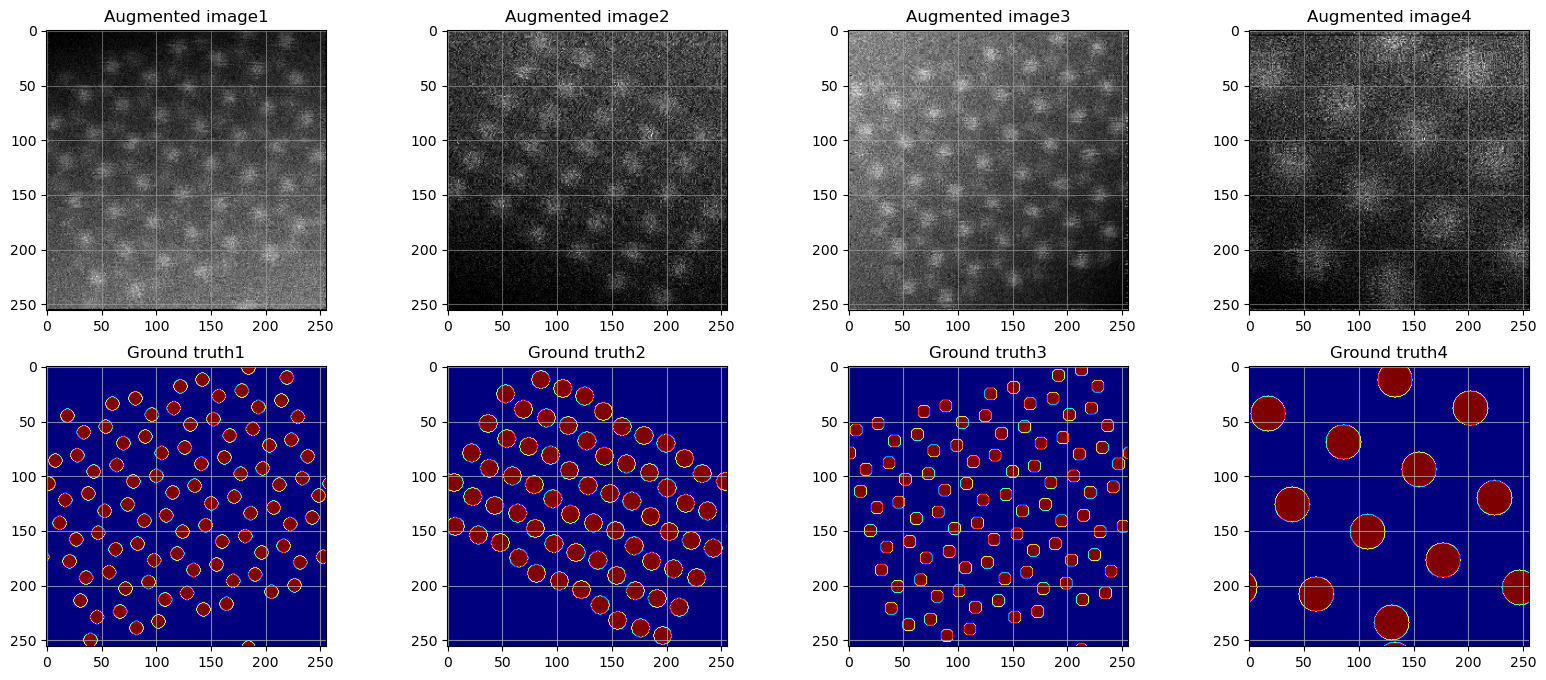

In [14]:
n = 5
fig = plt.figure(figsize=(25,8))
for i in range(1,n):
    ax = fig.add_subplot(2,n,i)
    ax.imshow(images[i-1].reshape(256,256), cmap='gray')
    ax.set_title('Augmented image' + str(i))
    ax.grid(alpha=0.5)
    ax = fig.add_subplot(2,n,i+n)
    #ax.imshow(labels[i-1])
    ax.imshow(labels[i-1].reshape(256,256),interpolation='Gaussian',cmap='jet')
    ax.set_title('Ground truth' + str(i))
    ax.grid(alpha=0.75)

In [15]:
# def trans(data):
#     data = np.array(data)
#     data = data.astype('float32')
#     data = torch.tensor(data)
#     return data

# images = trans(images)
# labels = trans(labels)
# images_test = trans(images_test)
# labels_test = trans(labels_test)
# #X_train,X_test,y_train,y_test = train_test_split(images,labels,test_size=0.2,random_state=42)

# 训练模型

In [16]:
#定义参数
class Args:
#    def __init__(self)->None:
    def __init__(self):
        self.batch_size = 4
        self.lr = 0.001
        self.epochs = 1
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.save_path = 'do_not_save.pth'

args = Args()

In [17]:
# 定义GetLoader类，继承Dataset方法，并重写__getitem__()和__len__()方法
class GetLoader(torch.utils.data.Dataset):
    #初始化函数，得到数据
    def __init__(self, image_path, label_path ,if_train = True):
        image_dir = os.listdir(image_path)
        image_name_list = [row.split('.')[0] for row in image_dir]
        image_path_list = []
        num = len(image_name_list)
        for i in range(num):
            image_i_path = image_path+image_name_list[i]+'.png'
            image_path_list.append(image_i_path)
        self.image_path_list = image_path_list
        
        label_dir = os.listdir(label_path)
        label_name_list = [row.split('.')[0] for row in label_dir]
        label_path_list = []
        num = len(label_name_list)
        for i in range(num):
            label_i_path = label_path+label_name_list[i]+'.png'
            label_path_list.append(label_i_path)
        self.label_path_list = label_path_list

        self.transform_image = torchvision.transforms.Compose([torchvision.transforms.Resize(256),
                                                         torchvision.transforms.ToTensor(),
                                                         torchvision.transforms.Normalize(0.5,0.5)])
        self.transform_label = torchvision.transforms.Compose([torchvision.transforms.Resize(256),
                                                         torchvision.transforms.ToTensor()])
        
        self.train_transform = [torchvision.transforms.RandomRotation(90,resample=Image.NEAREST),#随机旋转
                               torchvision.transforms.RandomVerticalFlip(p=0.5),#上下翻转，概率为0.5
                               torchvision.transforms.RandomHorizontalFlip(p=0.5),
                               torchvision.transforms.RandomResizedCrop(256,(0.5,1))#随机裁剪
                               ]
        self.add_noise = ["gaussian","poisson","salt","speckle"]
        
        self.if_train = if_train
        
    #index是根据batchsize划分数据后得到索引，最后将data和对应的labels进行一起返回
    def __getitem__(self,index):
        image_index_path = self.image_path_list[index]
        label_index_path = self.label_path_list[index]
        
        #数据增广
        image = Image.open(image_index_path).convert("L")
        label = Image.open(label_index_path).convert("L")
#         if self.if_train == True:
#             random_seed1 = random.randint(0,6)
#             random_seed2 = random.randint(0,6)
#             if random_seed1 < 4:
#                 random_trans = self.train_transform[random_seed1]
#                 image = random_trans(image)
#                 label = random_trans(label)
#             if random_seed2 < 4:
#                 image = np.array(image)
#                 random_noi = self.add_noise[random_seed2]
#                 image = random_noise(image, mode=random_noi)
#                 image = Image.fromarray(np.uint8(image * 255))
  
        image = self.transform_label(image)
        label = self.transform_label(label)
        
        return image,label
    
    #该函数返回数据大小长度，目的是DataLoader方便划分
    def __len__(self):
        return len(self.image_path_list)

# 通过GetLoader将数据进行加载，返回Dataset对象，包含data和labels
image_train_path = 'dataset/train/'
label_train_path = 'dataset/train_label/'
image_test_path = 'dataset/test/'
label_test_path = 'dataset/test_label/'
train_loader = GetLoader(image_train_path, label_train_path, if_train = True)
test_loader = GetLoader(image_test_path, label_test_path, if_train = False)

C:\Users\shiki\AppData\Local\Temp\ipykernel_13912\3815402906.py:29: DeprecationWarning: NEAREST is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.NEAREST or Dither.NONE instead.
  self.train_transform = [torchvision.transforms.RandomRotation(90,resample=Image.NEAREST),#随机旋转
D:\Software\python\lib\site-packages\torchvision\transforms\transforms.py:1297: UserWarning: The parameter 'resample' is deprecated since 0.12 and will be removed 0.14. Please use 'interpolation' instead.
  warnings.warn(


In [18]:
train_Loader = DataLoader(train_loader,batch_size=args.batch_size,shuffle=True,drop_last=True)
test_Loader = DataLoader(test_loader,batch_size=args.batch_size,shuffle=True)

In [19]:
class F1:
    def __init__(self, output, label):
        super(F1, self).__init__()
        #self.output = output.float().view(output[0],-1).cpu()
        self.output = output.float().view(1,-1)
        self.label = label.float().view(1,-1)
        self.tp1 = torch.sum(self.output * self.label, dim=1)
        self.tp_fp1 = torch.sum(self.output, dim=1)
        self.tp_fn1 = torch.sum(self.label, dim=1)
        self.tp2 = torch.sum((1 - self.output)*(1 - self.label), dim=1)
        self.tp_fp2 = torch.sum((1 - self.output), dim=1)
        self.tp_fn2 = torch.sum((1 - self.label), dim=1)
    
    def precision(self):
        return (self.tp1 + self.tp2)/(self.tp_fp1 + self.tp_fp2 + 0.0001)
    
    def recall(self):
        return (self.tp1 + self.tp2)/(self.tp_fn1+ self.tp_fn2 + 0.0001)
    
    def f1(self):
        precision = (self.tp1 + self.tp2)/(self.tp_fp1 + self.tp_fp2 + 0.0001)
        recall = (self.tp1 + self.tp2)/(self.tp_fn1+ self.tp_fn2 + 0.0001)
        return (1 + 0.3) * precision * recall / (0.3 * precision + recall + 0.0001)

In [20]:
#调整学习率
#lr_adjust = {
#            2:5e-5, 4:1e-5, 6:5e-6, 8:1e-6, 
#            10:5e-7, 15:1e-7, 20:5e-8
#            }
#if epoch in lr_adjust.keys():
#    lr = lr_adjust[epoch]
#    for param_group in optimizer.param_groups:
#        param_group['lr'] = lr
#    print('Updating learning rate to {}'.format(lr))

In [21]:
#Dice Loss
def dice_coeff(pred, target):
    smooth = 1.
    num = pred.size(0)
    m1 = pred.view(num, -1)  # Flatten
    m2 = target.view(num, -1)  # Flatten
    intersection = (m1 * m2).sum()
 
    return (2. * intersection + smooth) / (m1.sum() + m2.sum() + smooth)

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        self.epsilon = 1e-5
    
    def forward(self, predict, target):
        assert predict.size() == target.size(), "the size of predict and target must be equal."
        num = predict.size(0)
        
        pre = predict.view(num, -1)
        tar = target.view(num, -1)
        
        intersection = (pre * tar).sum(-1).sum()  #利用预测值与标签相乘当作交集
        union = (pre + tar).sum(-1).sum()
        
        score = 1 - 2 * (intersection + self.epsilon) / (union + self.epsilon)
        
        return score

In [22]:
#test
#out_111 = torch.tensor(out*max_out).reshape(1,256,256)
#ans111 = torch.tensor(ans).reshape(1,2,128,256)
#out_111 = ans111
#out_111 = out_111.view(1, -1)
#ans111 = ans111.view(1, -1)
#print(out_111)
#a = int(out_111.max(axis=1)[0].numpy())
#b = int(ans111.max(axis=1)[0].numpy())
#out_111 /=a
#ans111 /=b
#out_111 = torch.sigmoid(out_111)
#ans111 = torch.sigmoid(ans111)
#print(ans111)
#intersection = (out_111 * ans111).sum(-1).sum()  #利用预测值与标签相乘当作交集
#union = (out_111 + ans111).sum(-1).sum()
        
#score = 1 - 2 * (intersection + 0.01) / (union + 0.01)
#print(score)
#ans111.max(axis=1)[0]

In [23]:
#test
#a = torch.tensor([[[[1,0],[0,1]],[[0,1],[0,2]]]])
#a.size()
#a = torchvision.transforms.ToPILImage(a)
#plt.figure(figsize=(5,5))
#plt.imshow(a)
#print(a)

In [24]:
#os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
#CUDA_LAUNCH_BLOCKING = 1

In [25]:
"""
refer to https://github.com/jfzhang95/pytorch-deeplab-xception/blob/master/utils/metrics.py
"""
import numpy as np
__all__ = ['SegmentationMetric']
 
"""
confusionMetric  # 注意：此处横着代表预测值，竖着代表真实值，与之前介绍的相反
P\L     P    N
P      TP    FP
N      FN    TN
"""
class SegmentationMetric(object):
    def __init__(self, numClass):
        self.numClass = numClass
        self.confusionMatrix = np.zeros((self.numClass,)*2)
 
    def pixelAccuracy(self):
        # return all class overall pixel accuracy
        #  PA = acc = (TP + TN) / (TP + TN + FP + TN)
        acc = np.diag(self.confusionMatrix).sum() /  self.confusionMatrix.sum()
        return acc
 
    def classPixelAccuracy(self):
        # return each category pixel accuracy(A more accurate way to call it precision)
        # acc = (TP) / TP + FP
        classAcc = np.diag(self.confusionMatrix) / self.confusionMatrix.sum(axis=1)
        return classAcc # 返回的是一个列表值，如：[0.90, 0.80, 0.96]，表示类别1 2 3各类别的预测准确率
 
    def meanPixelAccuracy(self):
        classAcc = self.classPixelAccuracy()
        meanAcc = np.nanmean(classAcc) # np.nanmean 求平均值，nan表示遇到Nan类型，其值取为0
        return meanAcc # 返回单个值，如：np.nanmean([0.90, 0.80, 0.96, nan, nan]) = (0.90 + 0.80 + 0.96） / 3 =  0.89
 
    def meanIntersectionOverUnion(self):
        # Intersection = TP Union = TP + FP + FN
        # IoU = TP / (TP + FP + FN)
        intersection = np.diag(self.confusionMatrix) # 取对角元素的值，返回列表
        union = np.sum(self.confusionMatrix, axis=1) + np.sum(self.confusionMatrix, axis=0) - np.diag(self.confusionMatrix) # axis = 1表示混淆矩阵行的值，返回列表； axis = 0表示取混淆矩阵列的值，返回列表 
        IoU = intersection / union  # 返回列表，其值为各个类别的IoU
        mIoU = np.nanmean(IoU) # 求各类别IoU的平均
        return mIoU
 
    def genConfusionMatrix(self, imgPredict, imgLabel): # 同FCN中score.py的fast_hist()函数
        # remove classes from unlabeled pixels in gt image and predict
        mask = (imgLabel >= 0) & (imgLabel < self.numClass)
        label = self.numClass * imgLabel[mask] + imgPredict[mask]
        count = np.bincount(label, minlength=self.numClass**2)
        confusionMatrix = count.reshape(self.numClass, self.numClass)
        return confusionMatrix
 
    def Frequency_Weighted_Intersection_over_Union(self):
        # FWIOU =     [(TP+FN)/(TP+FP+TN+FN)] *[TP / (TP + FP + FN)]
        freq = np.sum(self.confusion_matrix, axis=1) / np.sum(self.confusion_matrix)
        iu = np.diag(self.confusion_matrix) / (
                np.sum(self.confusion_matrix, axis=1) + np.sum(self.confusion_matrix, axis=0) -
                np.diag(self.confusion_matrix))
        FWIoU = (freq[freq > 0] * iu[freq > 0]).sum()
        return FWIoU
 
 
    def addBatch(self, imgPredict, imgLabel):
        assert imgPredict.shape == imgLabel.shape
        self.confusionMatrix += self.genConfusionMatrix(imgPredict, imgLabel)
 
    def reset(self):
        self.confusionMatrix = np.zeros((self.numClass, self.numClass))
 
 
if __name__ == '__main__':
    imgPredict = np.array([0, 0, 1, 1, 2, 2]) # 可直接换成预测图片
    imgLabel = np.array([0, 0, 1, 1, 2, 2]) # 可直接换成标注图片
    metric = SegmentationMetric(2) # 3表示有3个分类，有几个分类就填几
    metric.addBatch(imgPredict, imgLabel)
    pa = metric.pixelAccuracy()
    cpa = metric.classPixelAccuracy()
    mpa = metric.meanPixelAccuracy()
    mIoU = metric.meanIntersectionOverUnion()
    print('pa is : %f' % pa)
    print('cpa is :') # 列表
    print(cpa)
    print('mpa is : %f' % mpa)
    print('mIoU is : %f' % mIoU)

pa is : 1.000000
cpa is :
[1. 1.]
mpa is : 1.000000
mIoU is : 1.000000


In [26]:
def trans(data):
    data = np.array(data)
    data = data.astype('float32')
    data = torch.tensor(data)
    return data

In [27]:
def train():
    model = net.cuda()
    #model = net.to(args.device)
    
    Loss = nn.CrossEntropyLoss()
    #Loss = nn.MSELoss()
    #Loss = DiceLoss()
    lr=args.lr
    optimizer = optim.Adam(net.parameters(),lr)
    #scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True,min_lr=1e10-5)
    #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,milestones=[10,50,100,150], gamma=0.1)
    
    train_epoch_loss = []
    val_epoch_loss = []
    min_accuracy = 0
    train_accuracy = []
    test_accuracy = []
    train_miou = []
    test_miou = []
    
    #恢复训练状态
    #resume = False
    resume = True
    if resume:
        checkpoint = torch.load('model_0.001.pth')
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        epoch = checkpoint['epoch']
        print("Start epoch:",epoch+1)

#     if resume:
#         #ckpt = args.save_path
#         ckpt = "best_accuracy_unet_0.1.pth"
#         model,optimizer,epoch = restore_from(model, optimizer,ckpt)
#         optimizer.state_steps = optimizer.state_steps.cpu()
#         #optimizer.load_state_dict(optimizer.state_dict())  # 将优化器状态转移到CUDA设备上
#         print("start epoch:",epoch+1)
#         #model.cuda()
    
    #创建log日志
    #logger = create_logger()
    #summary_writer = SummaryWriter(log_dir)


    #start train
    train_time = time.time()
    for epoch in range(args.epochs):
        #训练状态
        model.train()
        train_loss = []
        accuracy = 0
        mean_accuracy = 0
        mIoU = 0
        since_time = time.time()
        
#         #调整学习率
#         lr_adjust = {17:1e-2}
#         if epoch in lr_adjust.keys():
#             lr = lr_adjust[epoch]
#             for param_group in optimizer.param_groups:
#                 param_group['lr'] = lr
#             print('Epoch:{},Updating learning rate to {}'.format(epoch+1,lr))
        
        #使用自适应学习率，根据验证集的损失率调整学习率
#         for param_group in optimizer.param_groups:
#             if lr != param_group['lr']:
#                 lr = param_group['lr']
#                 print('Updating learning rate to {}'.format(param_group['lr']))
        
        for image,label in train_Loader:
        #for batch_idx,() in enumerate(train_Loader):
            image,label = trans(image),trans(label)
            image,label = image.cuda(),label.cuda()
            optimizer.zero_grad()#使用之前先清零
            output = model(image)
            #output = torch.softmax(output, dim = 1)
            #label = label.reshape(output.shape)
            #print(output.shape,label.shape,output.type(),label.type())
            #print(output.data)
            #output = output.reshape(label.shape)
            #output.shape = (1,1,256,256)
            
            #output = torch.sigmoid(output)
            #output = torch.threshold(output,0.5,0)
            #output = torch.softmax(output,dim = 1)
            loss = Loss(output,torch.squeeze(label).long())#loss反传，计算模型中各tensor的梯度
            
            output = torch.argmax(output,dim=1)
            output = output.unsqueeze(1)
            output = output.detach().cpu().numpy().astype(np.int64)
            label = label.detach().cpu().numpy().astype(np.int64)
            metric = SegmentationMetric(2)  # ()里面表示分类
            #print(output.dtype,label.dtype)
            metric.addBatch(output, label)
            mean_accuracy += metric.meanPixelAccuracy()
            mIoU += metric.meanIntersectionOverUnion()
            accuracy += metric.pixelAccuracy()
        
            loss.backward()
            optimizer.step()
            #optimizer.step()#用在每一个mini batch中，只有用了optimizer.step，模型才会更新
            #scheduler.step()
            train_loss.append(loss.item())
    
        #eval，验证状态，不是训练不需要梯度反传
        #在测试数据集上测试准确率
        model.eval()
        val_loss = []
        test_accuracy_i = 0
        test_mean_accuracy = 0
        test_mIoU = 0
        with torch.no_grad():
                for image,label in test_Loader:
                    image,label = trans(image),trans(label)
                    image,label = image.cuda(),label.cuda()
                    output = model(image)
                    #output = torch.softmax(output, dim = 1)
                    #output = output.reshape(label.shape)
                    #print(label.type)
                    
                    #output = torch.sigmoid(output)
                    #output = torch.threshold(output,0.5,0)
                    
#                     output = output.detach().cpu().numpy().transpose((1, 2, 0))
#                     _, output = cv2.threshold(output,0.5,1,cv2.THRESH_BINARY)
#                     output = torch.tensor(output.transpose((2,0,1)), dtype=torch.float32).cuda()
                    #output = torch.softmax(output,dim = 1)
                    loss = Loss(output,torch.squeeze(label).long())
                    #评估参数的保存
                    output = torch.argmax(output,dim=1)
                    output = output.unsqueeze(1)
                    output = output.detach().cpu().numpy().astype(np.int64)
                    label = label.detach().cpu().numpy().astype(np.int64)
                    #output已经转化为（N，1,256,256）的numpy数组
                    metric = SegmentationMetric(2)
                    metric.addBatch(output,label)
                    test_mean_accuracy += metric.meanPixelAccuracy()
                    test_mIoU += metric.meanIntersectionOverUnion()
                    test_accuracy_i += metric.pixelAccuracy()
                    val_loss.append(loss)
        
        #模型参数保存
        if test_mean_accuracy / len(test_Loader) > min_accuracy:
            #if epoch+1 == 10 or epoch >= args.epochs/10: #首次训练使用
            if epoch+1 == 10 or epoch >= 0:
            #将最优模型保存
                torch.save(
                    {'epoch':epoch,
                    'model_state_dict':model.state_dict(),
                    'optimizer_state_dict':optimizer.state_dict()},
                    "best_accuracy_unet.pth"
                          )
                print("best accuracy has saved:{:.4f} --- > {:.4f}".format(min_accuracy,(test_mean_accuracy / len(test_Loader))))
            min_accuracy = test_mean_accuracy / len(test_Loader)
        
        #print(epoch,args.epochs)

        if epoch + 1 == args.epochs:
            #save model
            torch.save(
                {'epoch':epoch,
                'model_state_dict':model.state_dict(),
                'optimizer_state_dict':optimizer.state_dict()},
                args.save_path
                      )
            print("train over")
        
#         if epoch%10 == 0:
#             for param_group in optimizer.param_groups:
#                 print("epoch:{},learning rate={}".format(epoch+1,param_group['lr']))

        train_accuracy.append(mean_accuracy / len(train_Loader))
        test_accuracy.append(test_mean_accuracy / len(test_Loader))
        train_miou.append(mIoU / len(train_Loader))
        test_miou.append(test_mIoU / len(test_Loader))
        
        train_loss = torch.tensor(train_loss, device='cpu')
        train_loss = np.average(train_loss)
        train_epoch_loss.append(train_loss)
        
        val_loss = torch.tensor(val_loss, device='cpu')
        val_loss = np.average(val_loss)
        val_epoch_loss.append(val_loss)
        
        #学习率优化
        #scheduler.step(val_loss)

        if (epoch)%1 == 0:
            print('-------------------Epoch:{}/{}\t ------------------\n'.format(epoch+1, args.epochs),
                 'Training Loss:{:.4f}\t Training Accuracy:{:.4f}\n'.format(train_loss, mean_accuracy/len(train_Loader)),
                 'Testing Loss:{:.4f}\t Testing Accuracy:{:.4f}\n'.format(val_loss, test_mean_accuracy/len(test_Loader)),
                 'Training MIoU:{:.4f}\t Testing MIoU:{:.4f}\n'.format(mIoU/len(train_Loader), test_mIoU / len(test_Loader)),
                 'Time: {:.4f}min'.format((time.time() - since_time) / 60))
    
    #plot the loss
    plt.figure(figsize=(25,25))
    plt.subplot(221)
    plt.plot(train_accuracy,'-o',label="train_acc")
    plt.plot(test_accuracy,'-o',label="val_acc")
    plt.title("epoch_acc")
    plt.subplot(222)
    plt.plot(train_epoch_loss,'-o',label="train_loss")
    plt.plot(val_epoch_loss,'-o',label="val_loss")
    plt.title("epoch_loss")
    plt.subplot(223)
    plt.plot(train_miou,'-o',label="train_mIoU")
    plt.plot(test_miou,'-o',label="val_mIoU")
    plt.title("epoch_mIoU")   
    plt.legend()
    plt.show
    
    return train_accuracy,test_accuracy,train_epoch_loss,val_epoch_loss,train_miou,test_miou


In [28]:
#读取数据
def restore_from(model,optimizer,ckpt_path):
    device = args.device
#    device = torch.cuda.current_device
    ckpt = torch.load(ckpt_path, map_location=lambda storage,loc:storage.cuda(device))
    #checkpoint_path
    
    epoch = ckpt['epoch']
#    ckpt_model_dict = remove_prefix(ckpt['state_dict'],'module.')
    model.load_state_dict(ckpt['model_state_dict']) #load model
    optimizer.load_state_dict(ckpt['optimizer_state_dict']) #load optimizer
    
    return model,optimizer,epoch

In [29]:
#错误原因，不应该对label进行norm的操作

# 训练结果

Start epoch: 22
best accuracy has saved:0.0000 --- > 0.9481
train over
-------------------Epoch:1/1	 ------------------
 Training Loss:0.3327	 Training Accuracy:0.9638
 Testing Loss:0.3405	 Testing Accuracy:0.9481
 Training MIoU:0.9338	 Testing MIoU:0.9112
 Time: 9.3059min


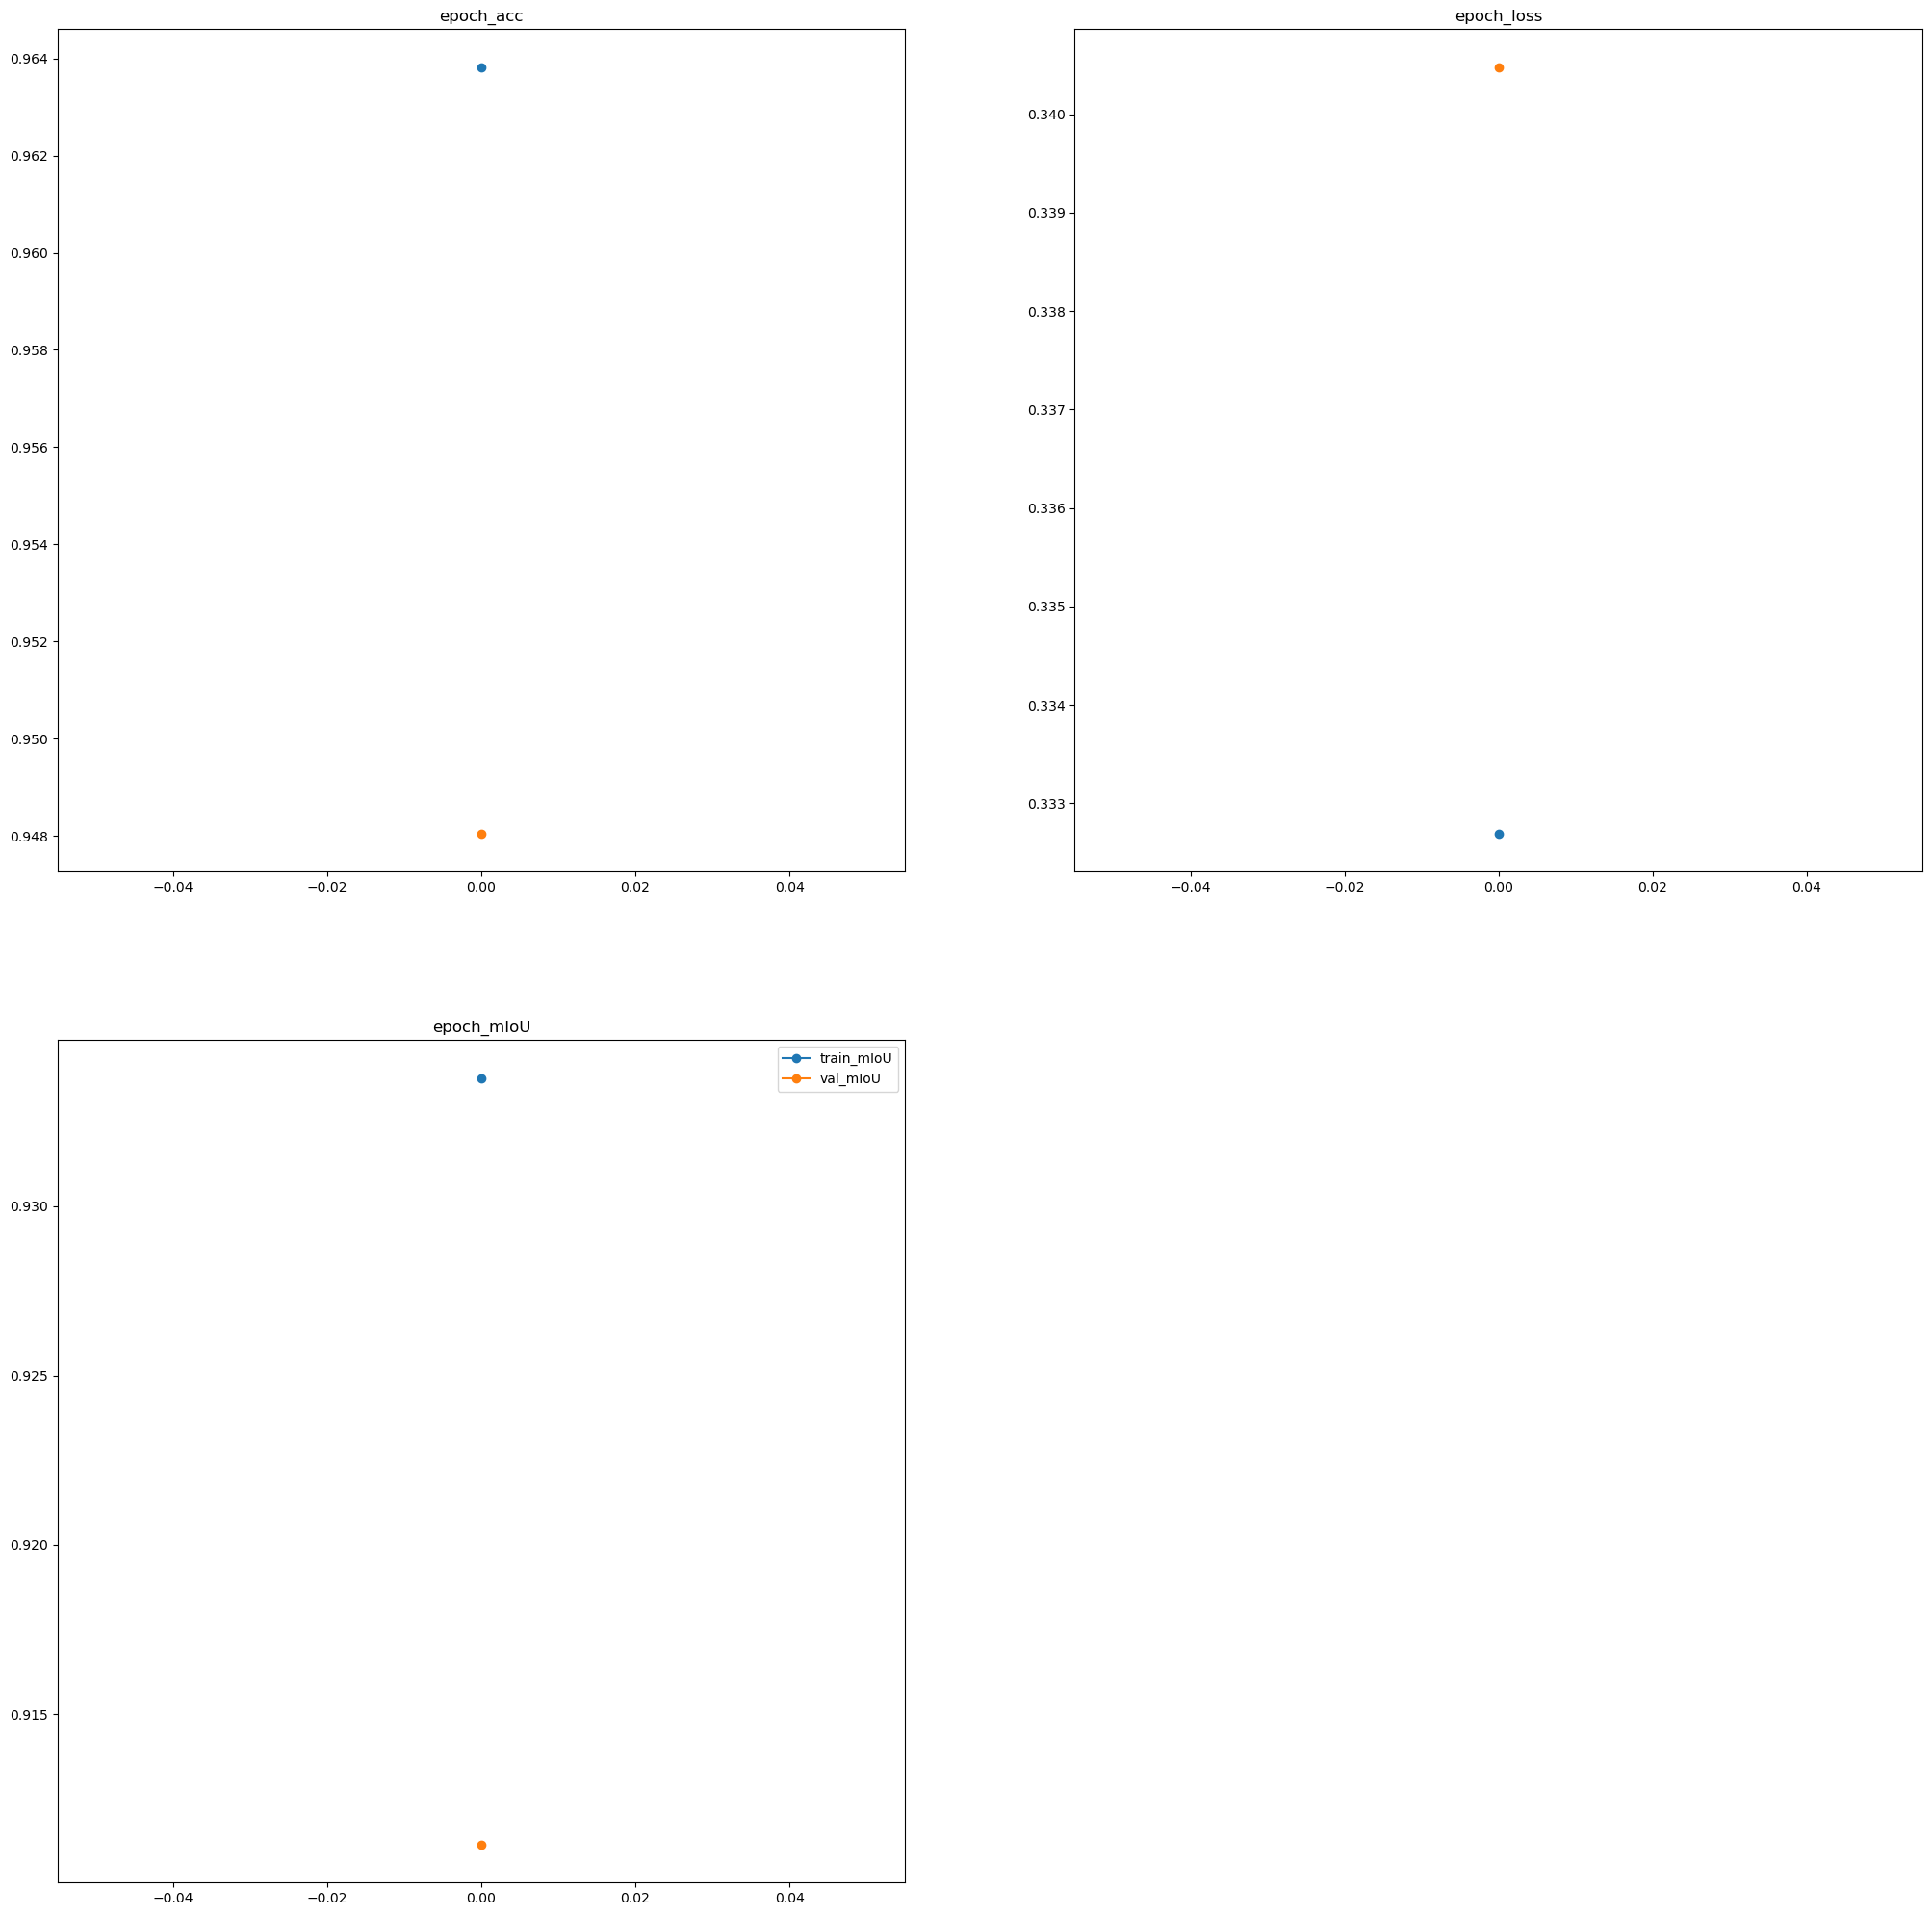

In [30]:
net = Unet()
train_accuracy,test_accuracy,train_epoch_loss,val_epoch_loss,train_miou,test_miou = train()

In [31]:
# 创建一个DataFrame对象
#train_accuracy,test_accuracy,train_epoch_loss,val_epoch_loss,train_miou,test_miou
#df = pd.DataFrame({'train_accuracy': train_accuracy})

# 将DataFrame保存到Excel文件
#df.to_excel('my_list.xlsx', index=False)

def save_lists_to_excel(file_path, list_dict):
    writer = pd.ExcelWriter(file_path)
    
    for sheet_name, data_list in list_dict.items():
        df = pd.DataFrame(data_list)
        df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    writer.save()
    print("保存Excel文件成功，处理结束")

train_out_dict = {
    'train_accuracy':train_accuracy,
    'test_accuracy':test_accuracy,
    'train_epoch_loss':train_epoch_loss,
    'val_epoch_loss':val_epoch_loss,
    'train_miou':train_miou,
    'test_miou':test_miou
}

save_lists_to_excel('train_out_0.001.xlsx', train_out_dict)

保存Excel文件成功，处理结束


In [32]:
X_test = torch.tensor([item.detach().numpy() for item in images_test]).cuda()
#X_test = torch.tensor(images_test).cuda()

C:\Users\shiki\AppData\Local\Temp\ipykernel_13912\340687536.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ..\torch\csrc\utils\tensor_new.cpp:204.)
  X_test = torch.tensor([item.detach().numpy() for item in images_test]).cuda()


In [48]:
index = 800
print(X_test[index].shape)
output_test = net(X_test[index].unsqueeze(0))
#表示在0处加一个为1的维度
print(output_test.shape)

torch.Size([1, 256, 256])
torch.Size([1, 2, 256, 256])


In [49]:
input_p = X_test[index,0]
print(input_p.shape)
test_p = labels_test[index]

torch.Size([256, 256])


1
0.0


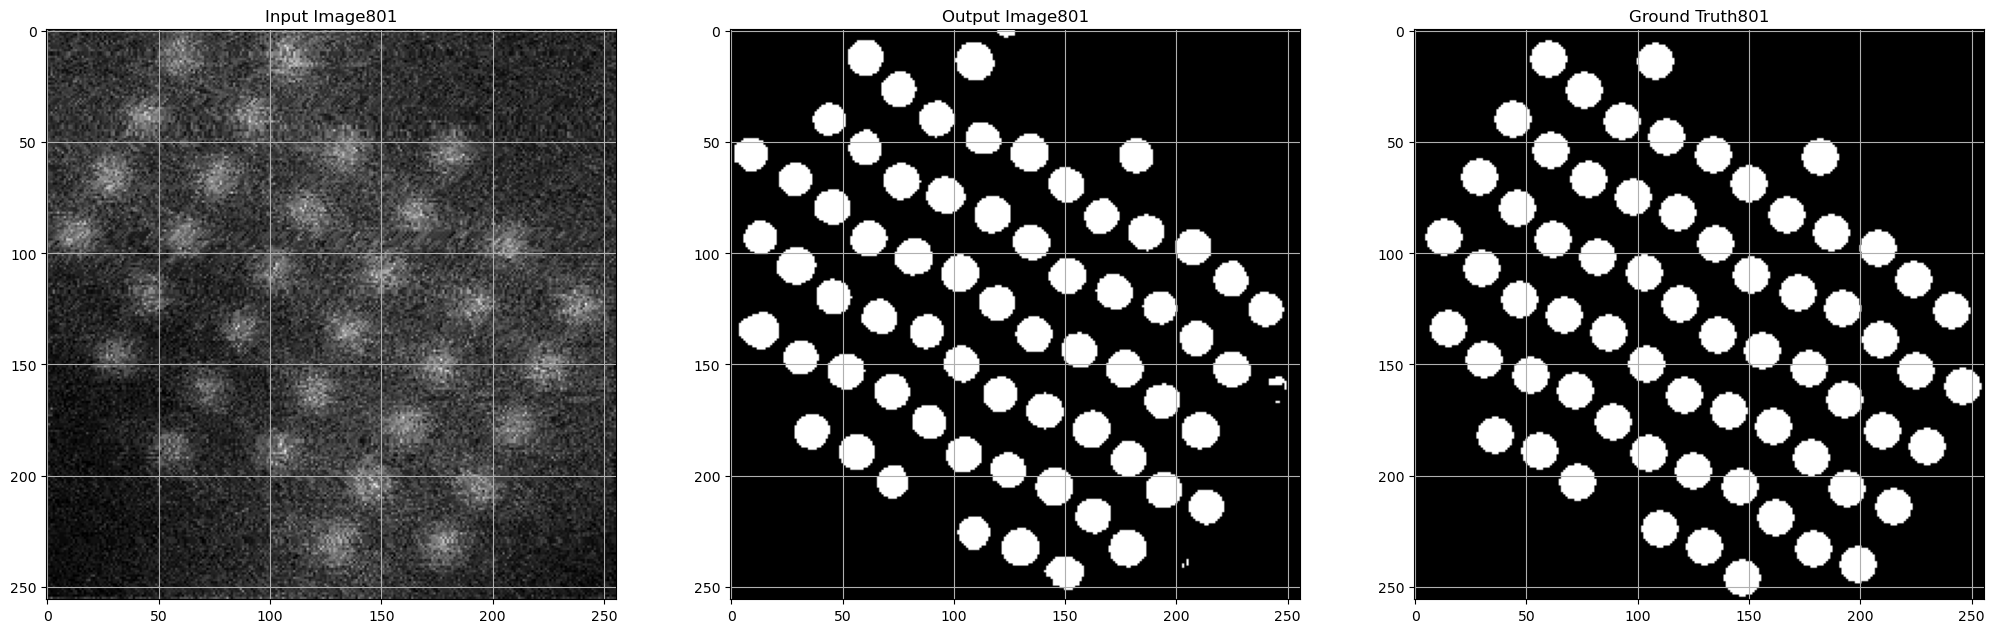

In [50]:
output_test = torch.softmax(output_test, dim = 1)
output_test = torch.argmax(output_test,dim=1)
out = output_test.detach().cpu().numpy()
print(out.max())
type(out)
input_1 = input_p.detach().cpu().numpy()
ans = test_p.detach().cpu().numpy()
ave = np.average(out)
# max_out = out.max()
# out = out/max_out
print(input_1.min())
plt.figure(figsize = (25,8))
plt.subplot(1,3,1)
#plt.imshow(input_1.reshape(256,256),cmap='gray')
plt.imshow(input_1.reshape(256,256),cmap='gray')
#保存numpy为png
cv2.imwrite("image_input.png", input_1.reshape(256,256)*255)
plt.title("Input Image" + str(index+1))
plt.grid(alpha=1)
plt.subplot(1,3,2)
plt.imshow(out.reshape(256,256),cmap='gray')
cv2.imwrite("image_output.png", out.reshape(256,256)*255)
plt.title('Output Image' + str(index+1))
plt.grid(alpha=1)
plt.subplot(1,3,3)
plt.imshow(ans.reshape(256,256),cmap='gray')
cv2.imwrite("ground_truth.png", ans.reshape(256,256)*255)
plt.title('Ground Truth' + str(index+1))
plt.grid(alpha=1)

# 读取数据，预测模型

In [ ]:
import cv2
import torchvision
from PIL import Image

In [ ]:
#对图片增加灰条，方式缩放失真
def pad_img(image,size):
    iw,ih = image.size
    w,h = size
    scale = min(w/iw,h/ih)
    nw = int(iw*scale)
    nh = int(ih*scale)
    
    image = image.resize((nw,nh),Image.BICUBIC)
    new_image = Image.new('L',size,color=0)
    new_image.paste(image,((w-nw)//2,(h-nh)//2))
    #左上的坐标
    return new_image,nw,nh

In [ ]:
def pred(img_path):
    #image = cv2.imread(img_path,0)
    image = Image.open(img_path)
    image = image.convert('L')
    image,nw,nh = pad_img(image,(256,256))
    
    #备份原图
    old_image = image
    box = (int((256-nw)//2),int((256-nh)//2),int(256-(256-nw)//2),int(256-(256-nh)//2))
    old_image = old_image.crop(box)
    
    transform1 = torchvision.transforms.Compose([torchvision.transforms.Resize((256,256)),
                                               torchvision.transforms.ToTensor()])
    transform2 = torchvision.transforms.ToPILImage()
    image = transform1(image)
    #写入日志，可以在pycharm通过tensorboard --logdir=logs --port=6007查看
    writer = SummaryWriter("logs")
    writer.add_image("origin_img",image)
    
    image = torch.reshape(image,(1,1,256,256))
    
    model = Unet()
    model.load_state_dict(torch.load(args.save_path)['model_state_dict'])
    model.eval()
    #使用model.eval()来固定dropout和归一化层，否则每次推理会生成不同的结果
    with torch.no_grad():
        output = model(image)
    #把输出图片也写入日志
    #writer.add_image("predict_img",output.reshape(1,256,256))
    writer.close()
    print(output.size())
    output = torch.argmax(output,dim=1)
    #print(output.size())
    output = torch.reshape(output,(256,256))
    aveput = np.average(output)
    max_output = output.max()
    output = output/max_output
    print(output[70:80,70:80])
    output = output.float()
    output = transform2(output)
    
    #把灰条部分截取
    output = output.crop(box)
    
    return old_image,output

In [ ]:
img_path = 'test1.jpg'
old_image,output = pred(img_path)
#将两张图片混合
image = Image.blend(old_image,output,0.5)
print(old_image)

plt.figure(figsize=(15,8))
plt.subplot(1,3,1)
#plt.imshow(old_image,cmap='gray')
plt.imshow(old_image,interpolation='Gaussian',cmap='jet')
plt.title("origin_img")
plt.grid(alpha=1)
plt.subplot(1,3,2)
plt.imshow(output,interpolation='Gaussian',cmap='jet')
plt.title("predict_img")
plt.grid(alpha=1)
plt.subplot(1,3,3)
plt.imshow(image,interpolation='Gaussian',cmap='jet')
plt.title("Contrast")
plt.grid(alpha=1)

In [ ]:
trans_totensor = torchvision.transforms.ToTensor()
output = output.convert("L")
output = trans_totensor(output).permute(1,2,0).numpy()
output = output.astype("uint8")
print(output.dtype)

output_ret1,output_ostu = cv2.threshold(output,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
output_guass = cv2.GaussianBlur(output,(5,5),0)
output_ret2,output_guass_ostu = cv2.threshold(output_guass,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

In [ ]:
output_images = [output, output_ostu, output_guass, output_guass_ostu]
title = ['Origin output', 'Histogram', 'Ostu\'s threshold',
         'Gauss output', 'Histogram', 'Gauss and Ostu\'s threshold']
plt.figure(figsize=(12,8))
for i in range(1,3):
    plt.subplot(2,3,3*(i-1)+1),plt.imshow(output_images[2*(i-1)],cmap='gray'),plt.title(title[3*(i-1)]) 
    plt.subplot(2,3,3*(i-1)+2),plt.hist(output_images[2*(i-1)].ravel(),256),plt.title(title[3*(i-1)+1])
    plt.subplot(2,3,3*(i-1)+3),plt.imshow(output_images[2*(i-1)+1],cmap='gray'),plt.title(title[3*(i-1)+2]) 

In [ ]:
#找中心、半径
#求方差
#对该半径内所有像素求灰度直方图，找峰位

In [ ]:
image = Image.open(img_path)
image = image.convert('L')
image,nw,nh = pad_img(image,(256,256))
    
#备份原图
old_image = Image.new('L',(256,256),color=0)
old_image.paste(image,(256,256))
old_image = image
#old_image = old_image.crop(int((256-nh)//2),int(256-(256-nh)//2),int((256-nw)//2),int(256-(256-nw)//2))
box = (int((256-nw)//2),int((256-nh)//2),int(256-(256-nw)//2),int(256-(256-nh)//2))
old_image = old_image.crop(box)
print(box)
print(old_image.size)

plt.figure('image',figsize=(2,2))
plt.imshow(old_image,interpolation='Gaussian',cmap='jet')
plt.show()

In [ ]:
#this is a test
img_path = 'test.png'
img_path1 = '6H 200kV JEOL DF  25MX 0028.jpg'
#img1 = Image.open(img_path)
img1 = cv2.imread(img_path1,0)
print(img1.shape)
img1 = img1[0:50,0:50]
tras = torchvision.transforms.ToTensor()
img_ten = tras(img1)
print(img_ten)
cv2.imshow("test",img1)
plt.hist(img1.ravel(),256)
plt.show()

cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import  cv2
def bi_demo(image):#高斯双边滤波
    dst = cv2.bilateralFilter(src=image, d=0, sigmaColor=150, sigmaSpace=10)
    cv2.namedWindow('bi_demo',0)
    cv2.resizeWindow('bi_demo',1024, 1024)
    cv2.imshow("bi_demo", dst)
    return dst

'''
    其中各参数所表达的意义：
    src：原图像；
    d：像素的邻域直径，可有sigmaColor和sigmaSpace计算可得；
    sigmaColor：颜色空间的标准方差，一般尽可能大；
    sigmaSpace：坐标空间的标准方差(像素单位)，一般尽可能小。'''

def mean_shift_demo(image):#均值偏移滤波
    dst = cv2.pyrMeanShiftFiltering(image, sp=15, sr=20)
    cv2.namedWindow('mean_shift image', 0)
    cv2.resizeWindow('mean_shift image', 1024, 1024)
    cv2.imshow("mean_shift image", dst)
    return dst


def median_demo(image):#中值滤波
    dst = cv2.medianBlur(image,5)
    cv2.namedWindow('median image', 0)
    cv2.resizeWindow('median image', 1024, 1024)
    cv2.imshow("median image", dst)
    return dst
    
def gauss_demo(image):#中值滤波
    dst = cv2.GaussianBlur(image, (5, 5), 0, 0)
    cv2.namedWindow('gauss image', 0)
    cv2.resizeWindow('gauss image',1024, 1024)
    cv2.imshow("gauss image", dst)
    return dst

def erode_demo(image):#中值滤波
    kernel = np.ones((5,5), np.uint8)  
    # 应用腐蚀操作  
    dst = cv2.erode(image, kernel, iterations = 1) 
    cv2.namedWindow('erode image', 0)
    cv2.resizeWindow('erode image',1024, 1024)
    cv2.imshow("erode image", dst)
    return dst


#使用均值边缘保留滤波时，可能会导致图像过度模糊
'''其中各参数所表达的意义：
    src：原图像;
    sp：空间窗的半径(The spatial window radius);
    sr：色彩窗的半径(The color window radius)'''

img_path1 = '6H 200kV JEOL DF  25MX 0028.jpg'
src = cv2.imread(img_path1)
bi = bi_demo(src)
mean = mean_shift_demo(src)
median = median_demo(src)
gauss = gauss_demo(src)
reode = erode_demo(src)
cv2.namedWindow('src', 0)
cv2.resizeWindow('src', 1024, 1024)
cv2.imshow('src',src)

bi = bi[0:50,0:50]
plt.hist(bi.ravel(),256)
plt.show()

cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
bi = bi[0:20,0:20]
plt.hist(bi.ravel(),256)
plt.show()

cv2.waitKey(0)
cv2.destroyAllWindows()